In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [18]:
# df1 = pd.read_csv("data_analysis.csv")
# df2 = pd.read_csv("data_visualization.csv")
# df3 = pd.read_csv("data_science.csv")

# df = pd.concat([df1, df2, df3], ignore_index=True)
# print(df.head())
# print(df.columns)


# df = pd.read_csv("data_analysis.csv")
df = pd.read_csv("data_visualization.csv")
# df = pd.read_csv("data_analysis.csv")
print(df.head())
# print(df.dtypes)

                    id      conversation_id               created_at  \
0  1406335989484822531  1406335989484822531  2021-06-20 01:10:03 IST   
1  1406292636789526537  1406292636789526537  2021-06-19 22:17:46 IST   
2  1406082288035811330  1406082288035811330  2021-06-19 08:21:55 IST   
3  1405948260796100610  1405948260796100610  2021-06-18 23:29:21 IST   
4  1405942146960613376  1405942146960613376  2021-06-18 23:05:03 IST   

         date      time  timezone    user_id      username  \
0  2021-06-20  01:10:03       530   16264836        apress   
1  2021-06-19  22:17:46       530   17818254  careersherpa   
2  2021-06-19  08:21:55       530   15808647    techreview   
3  2021-06-18  23:29:21       530  366154590  gurmanbhatia   
4  2021-06-18  23:05:03       530  239971233     cdcinjury   

                    name place  ... geo source user_rt_id user_rt retweet_id  \
0                 Apress   NaN  ... NaN    NaN        NaN     NaN        NaN   
1          Hannah Morgan   NaN  ..

/tmp/ipykernel_18903/3270737137.py:11: DtypeWarning: Columns (22,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_visualization.csv")


In [3]:

# print(df.head())
print(df.dtypes)

id                   int64
conversation_id      int64
created_at          object
date                object
time                object
timezone             int64
user_id              int64
username            object
name                object
place               object
tweet               object
language            object
mentions            object
urls                object
photos              object
replies_count        int64
retweets_count       int64
likes_count          int64
hashtags            object
cashtags            object
link                object
retweet               bool
quote_url           object
video                int64
thumbnail           object
near               float64
geo                float64
source             float64
user_rt_id         float64
user_rt            float64
retweet_id         float64
reply_to            object
retweet_date       float64
translate          float64
trans_src          float64
trans_dest         float64
dtype: object


In [4]:
def label(text):
    text = str(text).lower()
    
    positive_words = [
        "good","great","love","amazing","excellent","awesome",
        "useful","helpful","insightful","powerful","fast","efficient",
        "interesting","best","impressive","innovative","smart","easy"
    ]
    
    negative_words = [
        "bad","worst","hate","poor","terrible",
        "slow","difficult","hard","confusing","bug","error","issue",
        "problem","fail","wrong","boring","useless","inefficient"
    ]

    pos_score = sum(word in text for word in positive_words)
    neg_score = sum(word in text for word in negative_words)

    if pos_score > neg_score:
        return 1   # Positive
    elif neg_score > pos_score:
        return -1  # Negative
    else:
        return 0   # Neutral

df['target'] = df['tweet'].apply(label)

In [5]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean(text):
    text = str(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['tweet'].apply(clean)

[nltk_data] Downloading package stopwords to /home/te/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
cv = CountVectorizer(max_features=3000)
X = cv.fit_transform(df['clean_text'])
y = df['target']
print("Done")

Done


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# from sklearn.utils import resample

# df_pos = df[df.label == 1]
# df_neg = df[df.label == -1]

# # balance dataset
# if len(df_neg) > len(df_pos):
#     df_neg = resample(df_neg, replace=False, n_samples=len(df_pos), random_state=42)
# else:
#     df_pos = resample(df_pos, replace=False, n_samples=len(df_neg), random_state=42)

# df = pd.concat([df_pos, df_neg])

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [11]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9690695296523517


In [13]:
tweet = ["Data science is "]
tweet_clean = [clean(t) for t in tweet]
tweet_vec = cv.transform(tweet_clean)

pred = model.predict(tweet_vec)

if pred[0] == 1:
    print("Positive Tweet")
elif pred[0] == -1:
    print("Negative Tweet")
else:
    print("Neutral Tweet")

Neutral Tweet


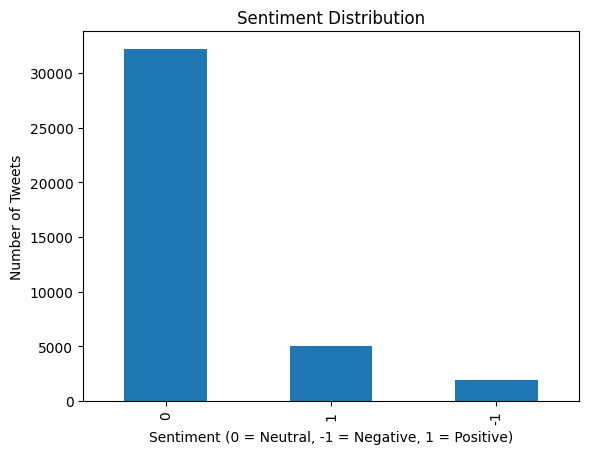

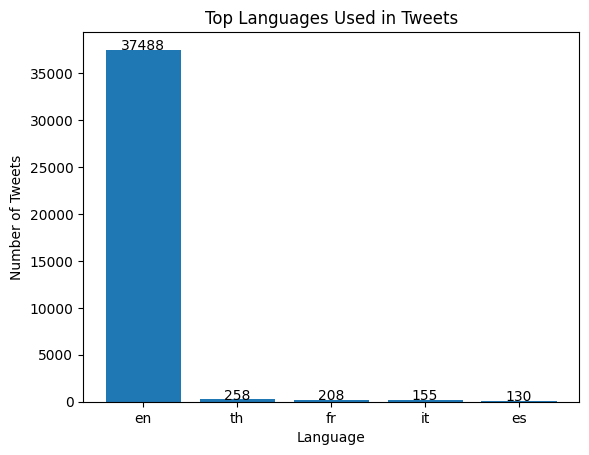

In [15]:

import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0 = Neutral, -1 = Negative, 1 = Positive)")
plt.ylabel("Number of Tweets")

plt.show()
lang_counts = df['language'].value_counts().head(5)

plt.bar(lang_counts.index, lang_counts.values)

for i, v in enumerate(lang_counts.values):
    plt.text(i, v, str(v), ha='center')

plt.title("Top Languages Used in Tweets")
plt.xlabel("Language")
plt.ylabel("Number of Tweets")

plt.show()


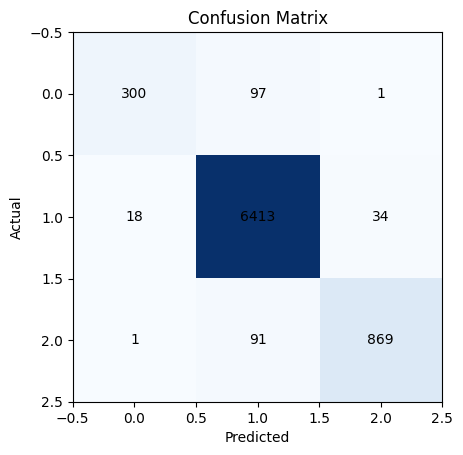

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm, cmap='Blues')

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()